# Chapter 3: Titanic Survived

In [61]:
from tools import load_data_csv
import pandas as pd

## Get the data

In [62]:
train_data = load_data_csv("datasets/titanic/train.csv")
test_data = load_data_csv("datasets/titanic/test.csv")

In [63]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


| Name | Description | Values |
| -----| ----------- | ------ |
| **PassengerId** | Id of the passenger | int|
| **Survived** | Survived Titanic's incident ?| 0 = N, 1 = Y| 
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Name** | Name | str|
| **Sex** | Sex | male, female |
| **Age** | Age | int |
| **SibSp** | # of siblings/spouses aboard | int |
| **Parch** | # of parents/childrens aboard | int |
| **Ticker** | Ticket number | int |
| **Fare** | Price of the ticker| float () |
| **Cabin** | Cabin Number | str|
| **Embarked** | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

First thing we can see is that their is a lot of data missing for **Cabin** feature. Then some ages are missing aswell, we can use the median or the mean to complete, and finally **Embarked** miss 2 values, we can get rid of those 2. Also we don't really care aboute Id or Name.

In [65]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Let's take a look to the distributions...

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

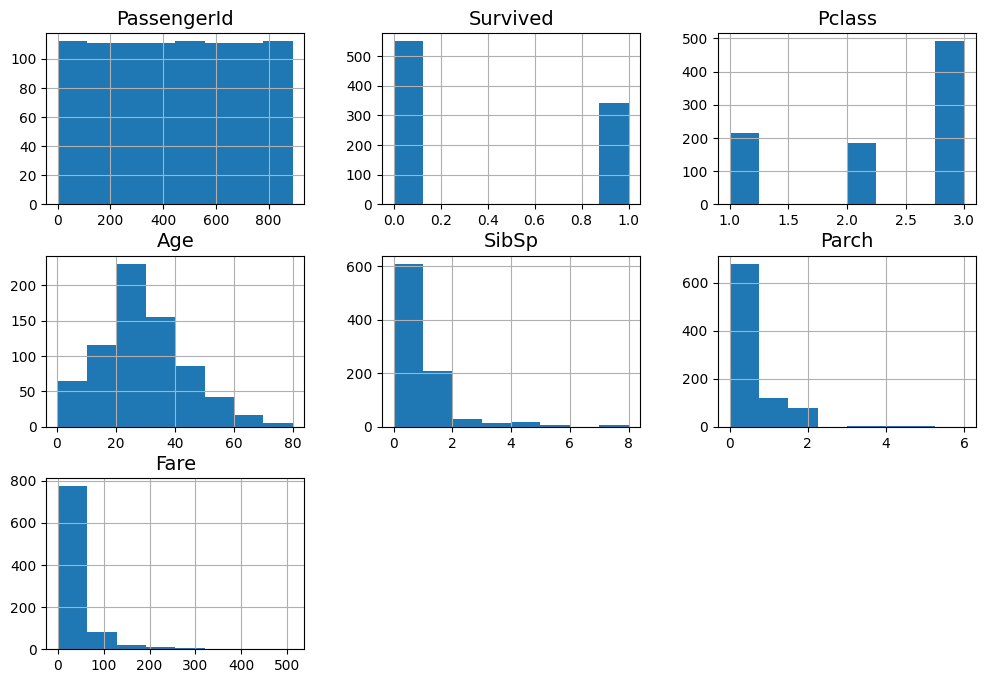

In [66]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

train_data.hist(bins=8, figsize=(12, 8))

Here, we can see that the mean age is around 30, also most of passengers didn't had siblings not parents aboard, and that the prices were mostly under 100$.

## Explore Data

In [67]:
explore_train = train_data.copy()
explore_train.set_index("PassengerId")

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [68]:
explore_train[explore_train["Sex"] == "male"]["Age"].median()

np.float64(29.0)

In [69]:
explore_train[explore_train["Sex"] == "female"]["Age"].mean()

np.float64(27.915708812260537)

In [70]:
explore_train["Age"].median()

np.float64(28.0)

Let's replace the sex by numerical features

In [71]:
explore_train["Sex"] = explore_train["Sex"].replace({"male": 0, "female": 1})

explore_train.head()

/tmp/ipykernel_24948/2032686020.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  explore_train["Sex"] = explore_train["Sex"].replace({"male": 0, "female": 1})


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


Here we can see that median age for female and male is 27 and 29 so we can imputate by 28 for both sex.

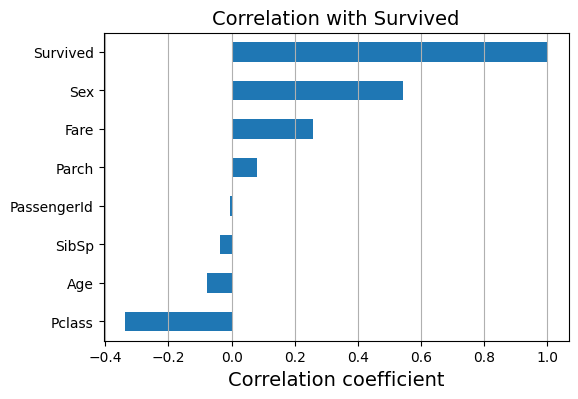

In [72]:
import matplotlib.pyplot as plt

corr = explore_train.corr(numeric_only=True)['Survived'].sort_values()

corr.plot(kind="barh", figsize=(6, 4))
plt.title("Correlation with Survived")
plt.xlabel("Correlation coefficient")
plt.grid(axis="x")
plt.show()

From what we can see from correlations is that the older you are and the lower is your class (eg. 3rd class), the lower your chances to survive are. Moreover, the more children/parents you have and the higher the price you paid, the heigher your chances to survive are. Finally, being a women gives your more chances to survive

## Prepare data

### Drop non significative features

In [73]:
train =  train_data.copy()

y_train = train["Survived"]
X_train = train.drop("Survived",axis=1)
X_train.set_index('PassengerId')


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [74]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import numpy as np

age_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("standard_scale", StandardScaler(with_mean=True))
                         ])

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("log_transform",FunctionTransformer(np.log1p,feature_names_out="one-to-one")),
    ("standard_scale",StandardScaler(with_mean=True))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])


In [75]:

preprocess = ColumnTransformer([
    ("age", age_pipeline, ["Age"]),
    ("num", num_pipeline, ["Fare", "SibSp", "Parch"]),
    ("cat", cat_pipeline, ["Embarked", "Sex", "Pclass"]),
], remainder="drop")


In [76]:
X_train_prepared = preprocess.fit_transform(X_train)

In [77]:
feature_names = preprocess.get_feature_names_out()
X_train_prepared = pd.DataFrame(X_train_prepared,columns=feature_names,index=X_train.index)
X_train_prepared.head()

,age__Age,num__Fare,num__SibSp,num__Parch,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Sex_female,cat__Sex_male,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3
0,-0.565736,-0.879741,0.889164,-0.52906,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.663861,1.361220,0.889164,-0.52906,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.258337,-0.798540,-0.609279,-0.52906,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,0.433312,1.062038,0.889164,-0.52906,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
4,0.433312,-0.784179,-0.609279,-0.52906,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


Let's compute the same operations on the test set.

In [78]:
X_test = test_data.copy()
X_test.set_index("PassengerId")

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [79]:
X_test_prepared = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()
X_test_prepared = pd.DataFrame(X_test_prepared,columns=feature_names,index=X_test.index)
X_test_prepared.head()

,age__Age,num__Fare,num__SibSp,num__Parch,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Sex_female,cat__Sex_male,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3
0,0.394887,-0.809683,-0.609279,-0.529060,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.355510,-0.911513,0.889164,-0.529060,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,2.508257,-0.612461,-0.609279,-0.529060,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.181487,-0.716562,-0.609279,-0.529060,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.565736,-0.387631,0.889164,1.155587,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [80]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [81]:
X_test_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age__Age         418 non-null    float64
 1   num__Fare        418 non-null    float64
 2   num__SibSp       418 non-null    float64
 3   num__Parch       418 non-null    float64
 4   cat__Embarked_C  418 non-null    float64
 5   cat__Embarked_Q  418 non-null    float64
 6   cat__Embarked_S  418 non-null    float64
 7   cat__Sex_female  418 non-null    float64
 8   cat__Sex_male    418 non-null    float64
 9   cat__Pclass_1    418 non-null    float64
 10  cat__Pclass_2    418 non-null    float64
 11  cat__Pclass_3    418 non-null    float64
dtypes: float64(12)
memory usage: 39.3 KB


Our data is now ready for ML.

## Promising Models

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

forest_clf = RandomForestClassifier(n_estimators=100,max_depth=5)

forest_scores = cross_val_score(forest_clf, X_train_prepared, y_train, cv=20)
forest_scores.mean()

np.float64(0.8225505050505051)

In [83]:
from sklearn.svm import SVC

svc_clf = SVC(gamma='auto') 
svc_scores = cross_val_score(svc_clf, X_train_prepared, y_train, cv=20)
svc_scores.mean()

np.float64(0.8293686868686869)

## Fine-tune the model

We are going to use random search

In [84]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint,loguniform

param_distributions = {
    'kernel': ['linear','poly','rbf','sigmoid'],
    'degree': randint(0, 5),
    'gamma': ['scale','auto'],
    'C': loguniform(1e-3, 1e3),
}

svc_clf = SVC()

rnd_search = RandomizedSearchCV(
    svc_clf, param_distributions=param_distributions,n_iter=20, cv=10,
    scoring='balanced_accuracy', random_state=42, verbose=1,n_jobs=-1)

rnd_search.fit(X_train_prepared, y_train)

Fitting 10 folds for each of 20 candidates, totalling 200 fits


/home/sebastian/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/sebastian/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/sebastian/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/late

,estimator,SVC()
,param_distributions,"{'C': <scipy.stats....x72109835bef0>, 'degree': <scipy.stats....x72109a500680>, 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'poly', ...]}"
,n_iter,20
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


Let's select the best model

In [85]:
best_model = SVC(**rnd_search.best_params_)
svc_scores = cross_val_score(best_model, X_train_prepared, y_train, cv=20)
svc_scores.mean()

np.float64(0.8248737373737374)

## Compute Predictions on Test set

In [86]:
best_model.fit(X_train_prepared,y_train)

,C,np.float64(0.5450293694558254)
,kernel,'rbf'
,degree,2
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [87]:
y_pred = best_model.predict(X_test_prepared)
y_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

Let's map the PassengerId to the predictions

In [91]:
submission_df = pd.DataFrame({'PassengerId': X_test["PassengerId"], "Survived": y_pred})
submission_df.set_index("PassengerId")
submission_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
submission_df.to_csv("results/03_titanic_results.csv",index=False)